In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [8]:
# Choose the used-cars CSV file from your computer
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Saving final_cars_datasets.csv to final_cars_datasets.csv
Shape: (2318, 11)


,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       2318 non-null   int64 
 1   price            2318 non-null   int64 
 2   mark             2318 non-null   object
 3   model            2318 non-null   object
 4   year             2318 non-null   int64 
 5   mileage          2318 non-null   int64 
 6   engine_capacity  2318 non-null   int64 
 7   transmission     2318 non-null   object
 8   drive            2318 non-null   object
 9   hand_drive       2318 non-null   object
 10  fuel             2318 non-null   object
dtypes: int64(5), object(6)
memory usage: 199.3+ KB


In [50]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   Unnamed: 0  price      mark    model  year  mileage  engine_capacity  \
0           0     80    nissan    march  2003    80000             1240   
1           1    110    nissan    march  2010    53000             1200   
2           2    165    nissan  lafesta  2005    47690             2000   
3           3    190    toyota  avensis  2008   130661             1990   
4           4    190  daihatsu     mira  2006    66300              660   

  transmission drive hand_drive      fuel  
0           at   2wd        rhd  gasoline  
1           at   2wd        rhd  gasoline  
2           at   2wd        rhd  gasoline  
3           at   2wd        rhd  gasoline  
4           at   2wd        rhd  gasoline  


In [52]:
print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())

Dataset shape: (2318, 11)
Column names:
['Unnamed: 0', 'price', 'mark', 'model', 'year', 'mileage', 'engine_capacity', 'transmission', 'drive', 'hand_drive', 'fuel']


In [10]:
print("Data types:")
print(df.dtypes)


Data types:
Unnamed: 0          int64
price               int64
mark               object
model              object
year                int64
mileage             int64
engine_capacity     int64
transmission       object
drive              object
hand_drive         object
fuel               object
dtype: object


In [53]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

In [55]:
print("Numerical variables:")
print(numerical_columns)

Numerical variables:
['Unnamed: 0', 'price', 'year', 'mileage', 'engine_capacity']


In [56]:
print("Categorical variables:")
print(categorical_columns)

Categorical variables:
['mark', 'model', 'transmission', 'drive', 'hand_drive', 'fuel']


In [13]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0         0
price              0
mark               0
model              0
year               0
mileage            0
engine_capacity    0
transmission       0
drive              0
hand_drive         0
fuel               0
dtype: int64


In [17]:
print("Total duplicate rows:",df.duplicated().sum())

Total duplicate rows: 0


In [66]:
print("Unique values in categorical columns:")
for column in categorical_columns:
  values = df[column].dropna().unique()
  print(f"{column}: {len(values)} unique values → {values[:5]}")

Unique values in categorical columns:
mark: 28 unique values → ['nissan' 'toyota' 'daihatsu' 'volkswagen' 'mazda']
model: 258 unique values → ['march' 'lafesta' 'avensis' 'mira' 'passat']
transmission: 3 unique values → ['at' 'mt' 'cvt']
drive: 3 unique values → ['2wd' '4wd' 'awd']
hand_drive: 3 unique values → ['rhd' 'center' 'lhd']
fuel: 5 unique values → ['gasoline' 'diesel' 'hybrid' 'lpg' 'cng']


In [30]:
rows_before = df.shape[0]
df = df.drop_duplicates().copy()
rows_after = df.shape[0]

In [33]:
print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before cleaning: 2318
Rows after cleaning: 2318
Duplicates removed: 0


In [63]:
from numpy._core import numeric
numeric_cols=df.select_dtypes(include="number")
print(numeric_cols)

      Unnamed: 0  price  year  mileage  engine_capacity
0              0     80  2003    80000             1240
1              1    110  2010    53000             1200
2              2    165  2005    47690             2000
3              3    190  2008   130661             1990
4              4    190  2006    66300              660
...          ...    ...   ...      ...              ...
2313        2331   1400  2009   121000              996
2314        2332   1400  2003   101000             3000
2315        2333   1400  2005   101000              660
2316        2334   1400  2000   170000              660
2317        2335   1400  2005    72320             3000

[2318 rows x 5 columns]


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       2318 non-null   int64 
 1   price            2318 non-null   int64 
 2   mark             2318 non-null   object
 3   model            2318 non-null   object
 4   year             2318 non-null   int64 
 5   mileage          2318 non-null   int64 
 6   engine_capacity  2318 non-null   int64 
 7   transmission     2318 non-null   object
 8   drive            2318 non-null   object
 9   hand_drive       2318 non-null   object
 10  fuel             2318 non-null   object
dtypes: int64(5), object(6)
memory usage: 199.3+ KB


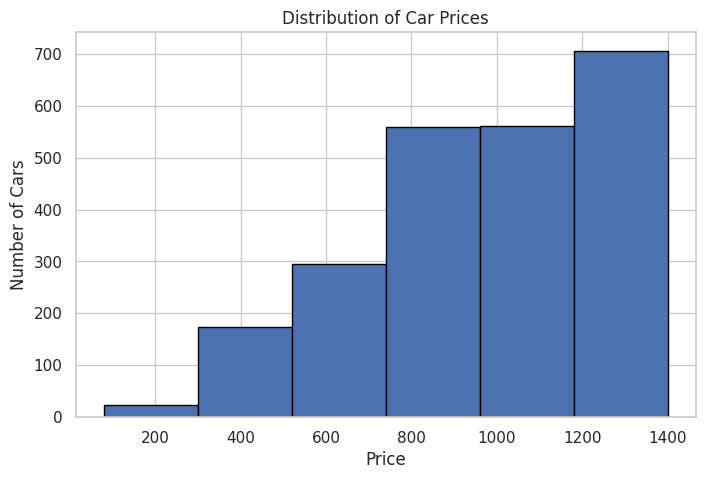

In [38]:
#Univariate Analysis
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=6, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

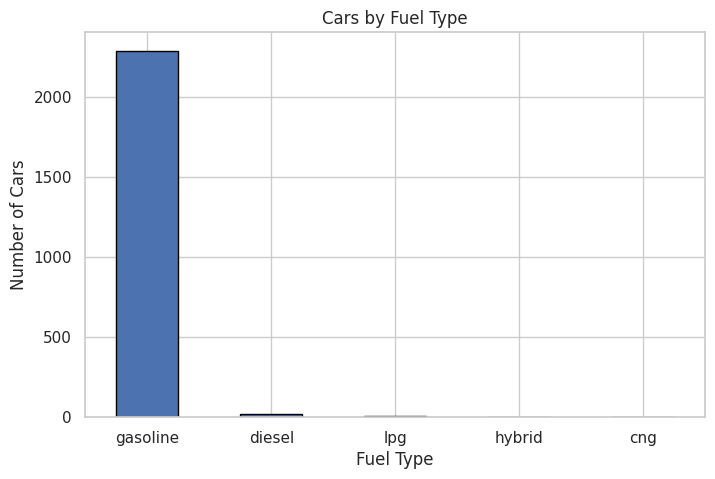

In [68]:
plt.figure(figsize=(8, 5))
df["fuel"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.show()

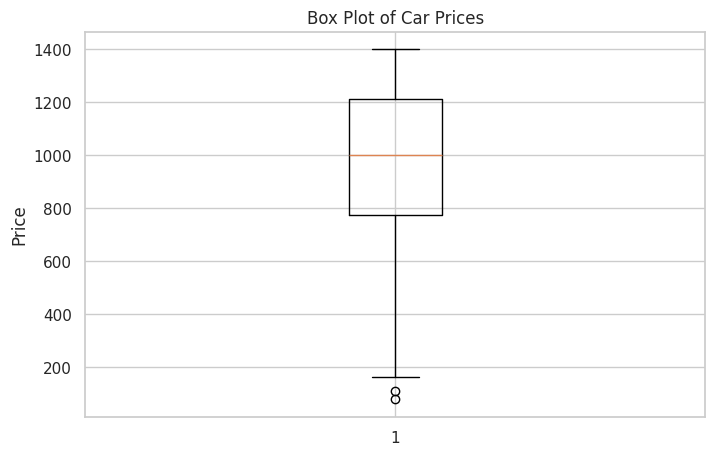

In [36]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["price"])
plt.title("Box Plot of Car Prices")
plt.ylabel("Price")
plt.show()

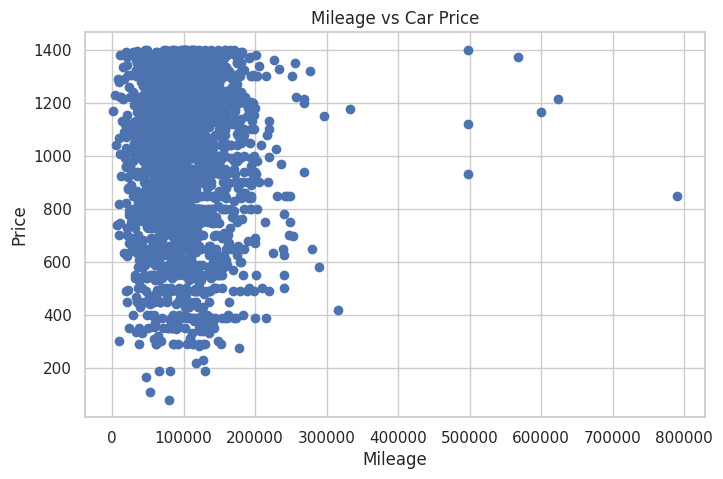

In [37]:
#Bivariate Analysis
plt.figure(figsize=(8, 5))
plt.scatter(df["mileage"], df["price"])
plt.title("Mileage vs Car Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

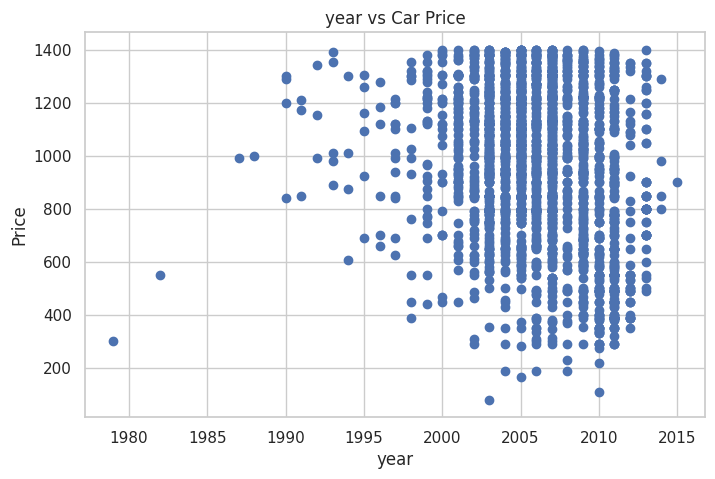

In [70]:
plt.figure(figsize=(8, 5))
plt.scatter(df["year"], df["price"])
plt.title("year vs Car Price")
plt.xlabel("year")
plt.ylabel("Price")
plt.show()


In [73]:
#Multivariate Analysis
correlation = df[numerical_columns].corr()

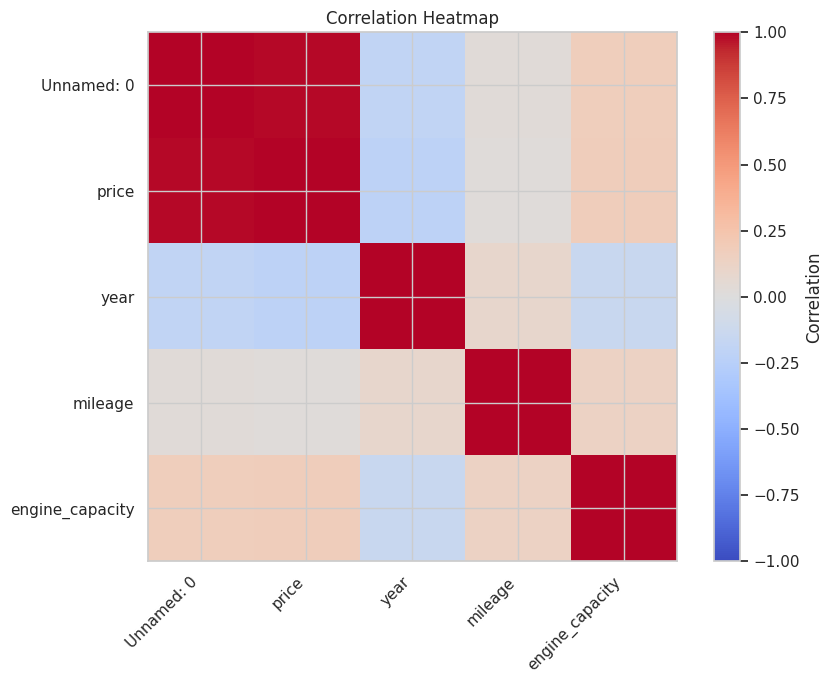

In [74]:
plt.figure(figsize=(9, 7))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numerical_columns)), numerical_columns, rotation=45, ha="right")
plt.yticks(range(len(numerical_columns)), numerical_columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [76]:
print("Correlation matrix:")
print(correlation)

Correlation matrix:
                 Unnamed: 0     price      year   mileage  engine_capacity
Unnamed: 0         1.000000  0.985100 -0.188326  0.028091         0.169773
price              0.985100  1.000000 -0.211092  0.021581         0.173748
year              -0.188326 -0.211092  1.000000  0.086065        -0.142460
mileage            0.028091  0.021581  0.086065  1.000000         0.130362
engine_capacity    0.169773  0.173748 -0.142460  0.130362         1.000000


In [43]:
#Outlier Check
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

In [44]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [45]:
price_outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

In [47]:
print("Price outlier records:")
print(price_outliers)

Price outlier records:
   Unnamed: 0  price    mark  model  year  mileage  engine_capacity  \
0           0     80  nissan  march  2003    80000             1240   
1           1    110  nissan  march  2010    53000             1200   

  transmission drive hand_drive      fuel  
0           at   2wd        rhd  gasoline  
1           at   2wd        rhd  gasoline  


In [77]:
#Final Findings
print("Final findings:")
print("1. The dataset contains", df.shape[0], "car records and", df.shape[1], "columns.")
print("2. The dataset contains numerical and categorical automobile attributes.")
print("3. Missing values and duplicate rows were checked before analysis.")
print("4. Car price varies across the vehicles in the dataset.")
print("5. Mileage and year show different relationships with price; the scatter plots help visualize these relationships.")
print("6. The correlation matrix shows relationships among the numerical variables.")


Final findings:
1. The dataset contains 2318 car records and 11 columns.
2. The dataset contains numerical and categorical automobile attributes.
3. Missing values and duplicate rows were checked before analysis.
4. Car price varies across the vehicles in the dataset.
5. Mileage and year show different relationships with price; the scatter plots help visualize these relationships.
6. The correlation matrix shows relationships among the numerical variables.
